In [1]:
import os
import cv2
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from tensorflow import keras
from keras import datasets, layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from imutils import paths

from sklearn.model_selection import train_test_split

In [2]:
def get_data(path: str) -> tuple[list, list]:
    
	files = os.listdir(path)
 
	labels = []
	data = []

	labels = [int(filename.split('.')[0] == 'dog') for filename in files]

	for file in files:
		image = cv2.imread(os.path.join(path, file))
		resized = cv2.resize(image, (32, 32))
		data.append(resized)

	data = np.array(data)
	labels = np.array(labels)

	data = data.reshape((len(labels), 3072))
	data = data / 255.0
 
	return (labels, data)

In [3]:
(labels_1000, data_1000) = get_data('./data/class_dataset/animals_1000/')
X_train, X_test, y_train, y_test = train_test_split(data_1000, labels_1000, test_size=0.2, random_state=5)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)

X_train shape: (800, 3072)
X_test shape: (200, 3072)
y_train shape: (800,)
y_test shape: (200,)


## Classical MLP

In [4]:
# Pure-dense MLP
model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(3072,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

optimizer = optimizers.Adam(learning_rate=0.0001)

model.compile(
    loss='binary_crossentropy',
	optimizer=optimizer,
	metrics=['accuracy']
)

callback = EarlyStopping(
    monitor='loss', 
    min_delta=0.00001,
    patience=10,
    restore_best_weights=True
)

model.summary()

/Users/jikaewsi/miniforge3/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │       196,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 198,785 (776.50 KB)

 Trainable params: 198,785 (776.50 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
history = model.fit(
    X_train, 
    y_train,
    epochs=500,
    batch_size=128,
    callbacks=[callback],
    verbose=1
)

Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5038 - loss: 0.7082  
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5713 - loss: 0.6829 
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5700 - loss: 0.6713 
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6125 - loss: 0.6658 
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6162 - loss: 0.6563 
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6300 - loss: 0.6525 
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6538 - loss: 0.6455 
Epoch 8/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6375 - loss: 0.6428 
Epoch 9/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6425 - loss: 0.6340 
Epoch 10/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6700 - loss: 0.6273 
Epoch 11/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7000 - loss: 0.6210 
Epoch 12/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6913 - lo

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


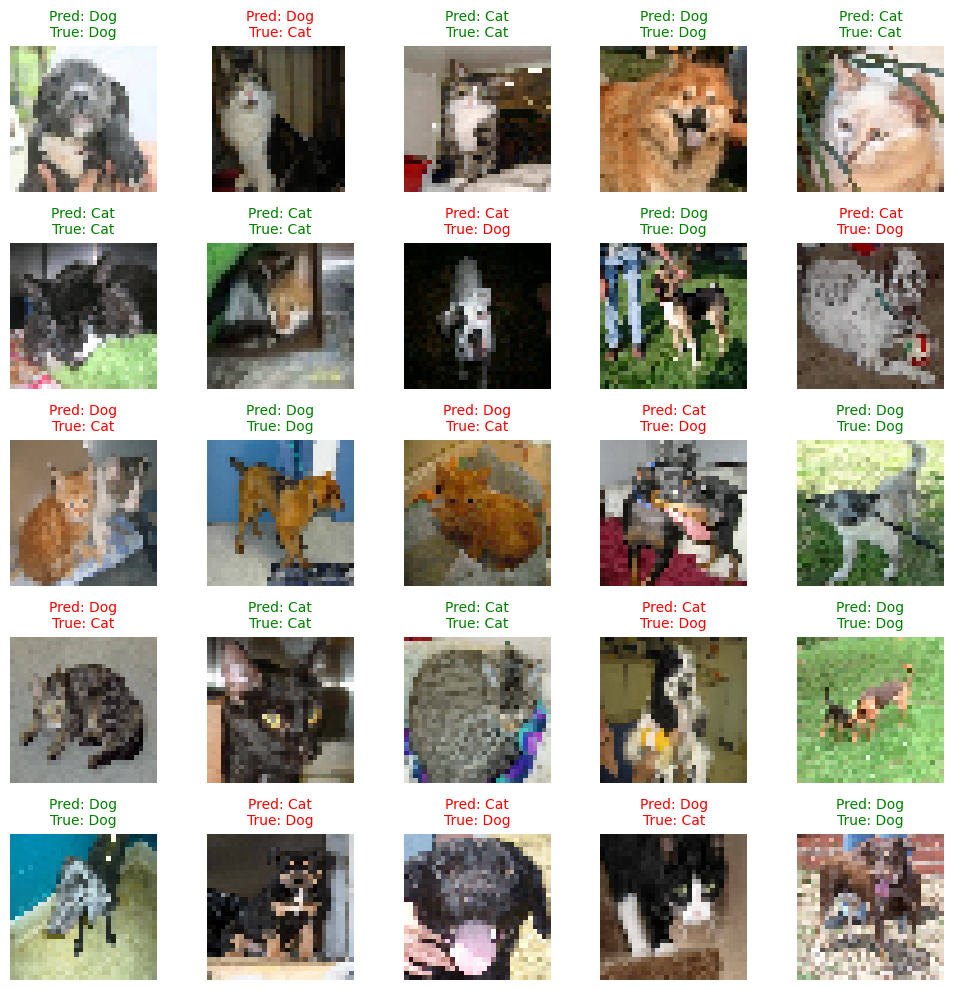

In [6]:
predictions = (model.predict(X_test) > 0.5).astype("int32")

num_images = 25
plt.figure(figsize=(10, 10))

for i in range(num_images):
    
    ax = plt.subplot(5, 5, i + 1)
    img = X_test[i].reshape(32, 32, 3)
    img = img.astype('float32')
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    
    pred_label = "Dog" if predictions[i] == 1 else "Cat"
    true_label = "Dog" if y_test[i] == 1 else "Cat"
    
    color = "green" if pred_label == true_label else "red"
    
    plt.title(f"Pred: {pred_label}\nTrue: {true_label}", color=color, fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

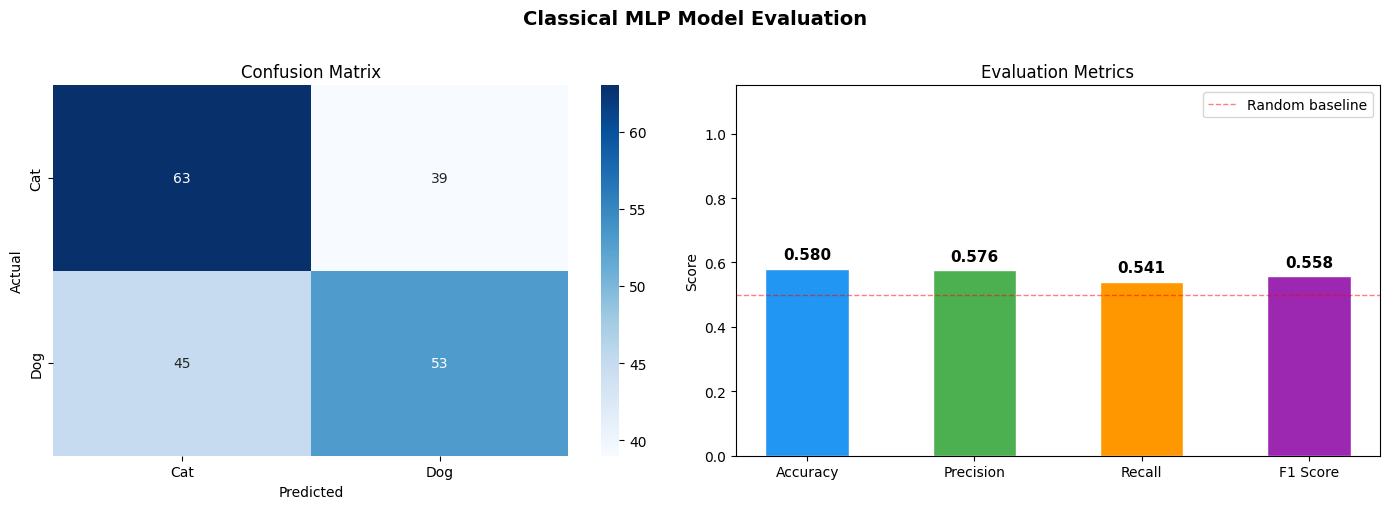


───────────────────────────────────
  Accuracy  : 0.5800  (58.00%)
  Precision : 0.5761
  Recall    : 0.5408
  F1 Score  : 0.5579
───────────────────────────────────


In [7]:
acc = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)
cm = confusion_matrix(y_test, predictions)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0],
    xticklabels=["Cat", "Dog"],
    yticklabels=["Cat", "Dog"],
)
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title("Confusion Matrix")

metric_names = ["Accuracy", "Precision", "Recall", "F1 Score"]
metric_values = [acc, precision, recall, f1]
bar_colors = ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0"]

bars = axes[1].bar(
    metric_names, metric_values, color=bar_colors, width=0.5, edgecolor="white"
)
axes[1].set_ylim(0, 1.15)
axes[1].set_title("Evaluation Metrics")
axes[1].set_ylabel("Score")
axes[1].axhline(
    y=0.5, color="red", linestyle="--", linewidth=1, alpha=0.5, label="Random baseline"
)
axes[1].legend()

for bar, val in zip(bars, metric_values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{val:.3f}",
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=11,
    )

plt.suptitle("Classical MLP Model Evaluation", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print(f"\n{'─'*35}")
print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print(f"{'─'*35}")

## CNN

In [8]:
X_train_cnn = X_train.reshape(-1, 32, 32, 3)
X_test_cnn  = X_test.reshape(-1, 32, 32, 3)

In [14]:
cnn_model = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2,2)), # → 16×16
    layers.Dropout(0.2),

    # Block 2
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)), # → 8×8
    layers.Dropout(0.3),
    
    # Block 3
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),  # 8×8 → 4×4
    layers.Dropout(0.3),

    # Head
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')

], name='CNN')

optimizer = optimizers.Adam(learning_rate=1e-4)

cnn_model.compile(
    loss='binary_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

callback = EarlyStopping(
    monitor='val_loss',
    min_delta=1e-7,
    patience=10,
    restore_best_weights=True
)

cnn_model.summary()

/Users/jikaewsi/miniforge3/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,649 (1.36 MB)

 Trainable params: 355,649 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history = cnn_model.fit(
    X_train_cnn, y_train,
    validation_data=(X_test_cnn, y_test),
    epochs=500,
    batch_size=128,
    callbacks=[callback]
)

Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.5100 - loss: 0.6946 - val_accuracy: 0.4700 - val_loss: 0.6931
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.5100 - loss: 0.6986 - val_accuracy: 0.5150 - val_loss: 0.6931
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.5150 - loss: 0.6937 - val_accuracy: 0.5000 - val_loss: 0.6929
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.5125 - loss: 0.6953 - val_accuracy: 0.5150 - val_loss: 0.6928
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.4988 - loss: 0.6976 - val_accuracy: 0.5100 - val_loss: 0.6927
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.5025 - loss: 0.6968 - val_accuracy: 0.5350 - val_loss: 0.6922
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.5163 - loss: 0.6942 - val_accuracy: 0.5100 - val_loss: 0.6920
Epoch 8/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.5175 - loss: 0.6927 - val_accuracy: 0.5100 - val_loss:

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


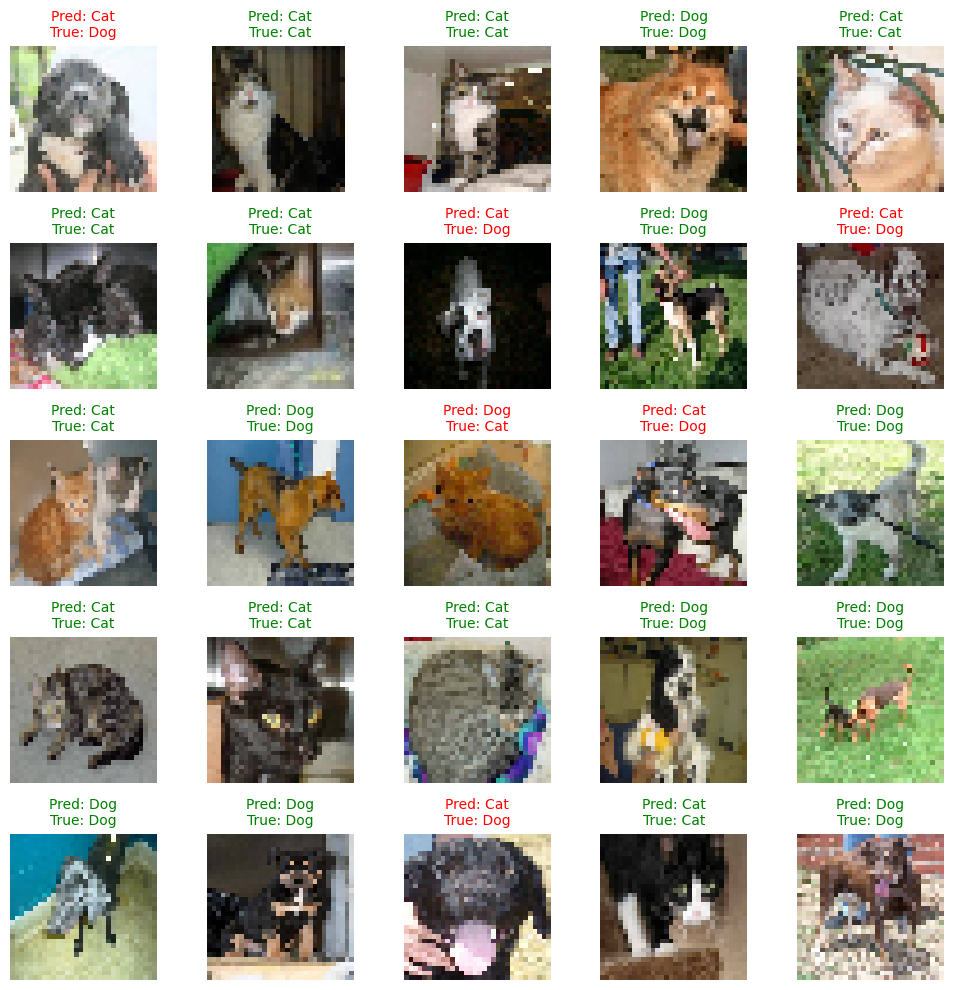

In [16]:
predictions = (cnn_model.predict(X_test_cnn) > 0.5).astype("int32")

num_images = 25
plt.figure(figsize=(10, 10))

for i in range(num_images):
    
    ax = plt.subplot(5, 5, i + 1)
    img = X_test[i].reshape(32, 32, 3)
    img = img.astype('float32')
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    
    pred_label = "Dog" if predictions[i] == 1 else "Cat"
    true_label = "Dog" if y_test[i] == 1 else "Cat"
    
    color = "green" if pred_label == true_label else "red"
    
    plt.title(f"Pred: {pred_label}\nTrue: {true_label}", color=color, fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

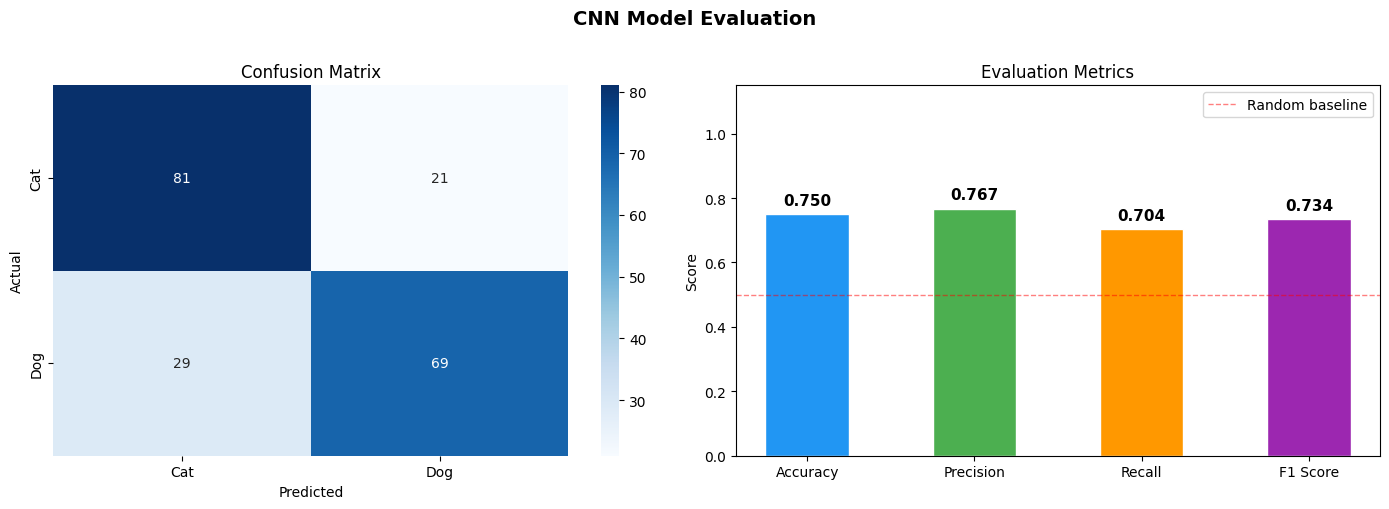


───────────────────────────────────
  Accuracy  : 0.7500  (75.00%)
  Precision : 0.7667
  Recall    : 0.7041
  F1 Score  : 0.7340
───────────────────────────────────


In [17]:
acc = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)
cm = confusion_matrix(y_test, predictions)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0],
    xticklabels=["Cat", "Dog"],
    yticklabels=["Cat", "Dog"],
)
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title("Confusion Matrix")

metric_names = ["Accuracy", "Precision", "Recall", "F1 Score"]
metric_values = [acc, precision, recall, f1]
bar_colors = ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0"]

bars = axes[1].bar(
    metric_names, metric_values, color=bar_colors, width=0.5, edgecolor="white"
)
axes[1].set_ylim(0, 1.15)
axes[1].set_title("Evaluation Metrics")
axes[1].set_ylabel("Score")
axes[1].axhline(
    y=0.5, color="red", linestyle="--", linewidth=1, alpha=0.5, label="Random baseline"
)
axes[1].legend()

for bar, val in zip(bars, metric_values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{val:.3f}",
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=11,
    )

plt.suptitle("CNN Model Evaluation", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print(f"\n{'─'*35}")
print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print(f"{'─'*35}")

<Axes: >

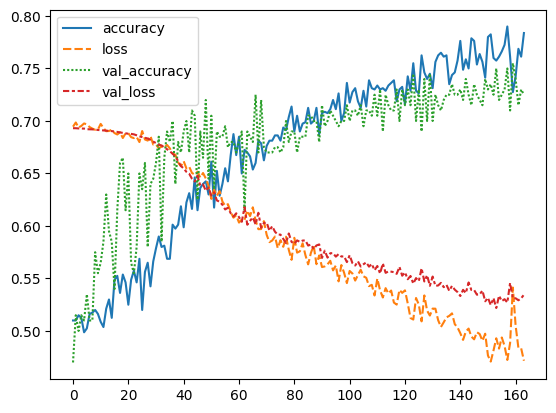

In [18]:
sns.lineplot(history.history)